# Generating Embeddings using Hugging Face (Free models)
**Level:** Scratch → Intermediate**Runs on:** Google Colab (Free CPU/GPU)
### What you will learn
1. What an embedding is (in simple words)
2. Installing free, open Hugging Face libraries
3. Generating embeddings with `sentence-transformers`
4. Comparing text similarity using cosine similarity
5. Visualizing embeddings in 2D
6. Building a mini Semantic Search engine (intermediate project)
  > No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.

## 1. What is an Embedding?
An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text.
- Similar sentences → similar (close) vectors.
- Different sentences → far apart vectors.

Example:
- "I love dogs" and "I like puppies" → vectors will be **close**
- "I love dogs" and "The stock market crashed" → vectors will be **far apart**We will use the `sentence-transformers` library, which uses free Hugging Face models.

### 2. Install Required LibrariesRun this once. `-q` keeps the output quiet (low token / clean output).

In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib

### 3. Load a Free Hugging Face ModelWe are using **`
all-MiniLM-L6-v2`** — a small, fast, completely free open-source model from Hugging
Face.- Size: ~80MB
- Great for learning and even production use- Output: 384-dimensional embedding vector per sentence

In [ ]:
from sentence_transformers import SentenceTransformer
# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


### 4. Generate Your First Embedding

In [ ]:
sentence = "I love learning about Artificial Intelligence."
embedding = model.encode(sentence)
print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634455 -0.0765703   0.04107474  0.01962832  0.05804764 -0.05071755
  0.03889348  0.03076576  0.05800403  0.06948569]


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the *meaning* of the sentence.

### 5. Generate Embeddings for Multiple Sentences

In [ ]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
  ]
embeddings = model.encode(sentences)
print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


### 6. Measure Similarity Between SentencesWe use **Cosine Similarity** to check how close two embeddings are.
- Score close to `1` → very similar meaning
- Score close to `0` → unrelated meaning
- Score close to `-1` → opposite meaning (rare with text)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)
import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


**Important Discussion Point:**Look at the similarity score between *"I love dogs"* and *"I like puppies"* — it should be high.Compare that to *"I love dogs"* vs *"The stock market crashed today"* — it should be low.This is the **core idea behind semantic search, chatbots, and recommendation systems**.

### 7. Visualize Embeddings in 2D (using PCA)Embeddings have 384 dimensions
— we can't see that. So we reduce it to 2D just to *visualize* how sentences cluster.

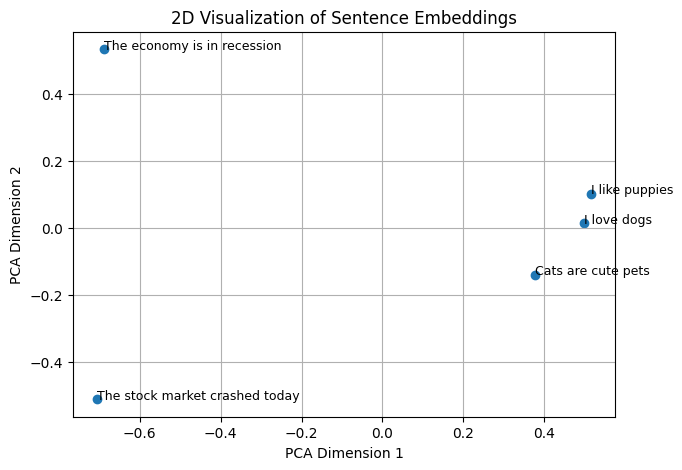

In [17]:
# Fallback block: Ensure sentences and embeddings exist in the current session
try:
    embeddings
    sentences
except NameError:
    sentences = [
        "I love dogs",
        "I like puppies",
        "The stock market crashed today",
        "Cats are cute pets",
        "The economy is in recession"
    ]
    # If the model is also not loaded, initialize it
    try:
        model
    except NameError:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(sentences)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])
for i, sent in enumerate(sentences):
  plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)
plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear **closer together** in the plot, even though we never told the model to group them manually.

## 8. Intermediate Project: Mini Semantic Search Engine
**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.

In [18]:
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

print("Number of documents:", len(documents))

for i, doc in enumerate(documents):
    print(f"{i}: {doc}")

Number of documents: 6
0: Python is a popular programming language for AI.
1: The weather today is sunny and warm.
2: Machine learning models learn patterns from data.
3: I enjoy playing football on weekends.
4: Deep learning uses neural networks with many layers.
5: Paris is the capital city of France.


In [20]:
doc_embeddings = model.encode(documents)

print("Embedding shape:", doc_embeddings.shape)

Embedding shape: (6, 384)


In [26]:
def semantic_search(query, top_k=2):

    # Convert the query into an embedding
    query_embedding = model.encode([query])

    # Calculate similarity between query and all documents
    scores = cosine_similarity(
        query_embedding,
        doc_embeddings
    )[0]

    # Sort documents from highest similarity to lowest
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")

    for idx in ranked_idx:
        print(
            f"Score: {scores[idx]:.3f} | {documents[idx]}"
        )

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

semantic_search("Tell me about AI and neural networks")

Query: Tell me about AI and neural networks

Score: 0.534 | Deep learning uses neural networks with many layers.
Score: 0.524 | Python is a popular programming language for AI.


In [28]:
# Try another query
semantic_search("What is the capital of France?")

Query: What is the capital of France?

Score: 0.824 | Paris is the capital city of France.
Score: 0.102 | Python is a popular programming language for AI.


### 9. Key Takeaways (Recap for Students)
                  | Concept | Meaning ||---|---||
                  Embedding | Numeric vector representing meaning of text
                  || Model used | `all-MiniLM-L6-v2` (free, open-source, Hugging Face)
                  || Cosine Similarity | Measures how close two embeddings are
                  || Semantic Search | Finding relevant text by meaning, not exact words
                  || PCA | Used only to visualize high-dimension vectors in 2D |###
                  
    10. Practice Exercises (for students)
    1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.
    2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.
    3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.

In [40]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create 10 different documents
documents = [
    "Artificial intelligence enables machines to perform intelligent tasks.",
    "Cloud computing provides computing resources through the internet.",
    "Cybersecurity protects computers and networks from digital attacks.",
    "Python is commonly used for artificial intelligence and data science.",
    "Docker packages applications with their required dependencies.",
    "GitHub is used to store and collaborate on software projects.",
    "APIs allow different software applications to communicate with each other.",
    "Natural language processing helps computers understand human language.",
    "Databases are used to store and organize application data.",
    "DevOps combines software development and IT operations."
]

# Generate embeddings
document_embeddings = model.encode(documents)

# Semantic search function
def search_documents(query, top_k=3):

    # Convert query into embedding
    query_embedding = model.encode(query)

    # Calculate cosine similarity manually
    scores = np.dot(document_embeddings, query_embedding) / (
        np.linalg.norm(document_embeddings, axis=1)
        * np.linalg.norm(query_embedding)
    )

    # Get highest similarity scores
    ranked_results = np.argsort(scores)[::-1][:top_k]

    print("\nQuery:", query)
    print("\nTop Matching Documents:")

    for rank, index in enumerate(ranked_results, start=1):
        print(
            f"{rank}. {documents[index]}"
            f" --> Similarity: {scores[index]:.4f}"
        )


# Test different queries
search_documents("How do computers become intelligent?")

search_documents("How can I protect my computer from hackers?")

search_documents("What technology helps applications communicate?")

search_documents("How can I store application information?")

search_documents("What is used for deploying applications?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Query: How do computers become intelligent?

Top Matching Documents:
1. Artificial intelligence enables machines to perform intelligent tasks. --> Similarity: 0.5777
2. Natural language processing helps computers understand human language. --> Similarity: 0.4833
3. Python is commonly used for artificial intelligence and data science. --> Similarity: 0.3163

Query: How can I protect my computer from hackers?

Top Matching Documents:
1. Cybersecurity protects computers and networks from digital attacks. --> Similarity: 0.5132
2. Cloud computing provides computing resources through the internet. --> Similarity: 0.1043
3. GitHub is used to store and collaborate on software projects. --> Similarity: 0.0994

Query: What technology helps applications communicate?

Top Matching Documents:
1. APIs allow different software applications to communicate with each other. --> Similarity: 0.5488
2. Natural language processing helps computers understand human language. --> Similarity: 0.4057
3. Databa

In [41]:
from sentence_transformers import SentenceTransformer
import numpy as np

documents = [
    "HTML creates the basic structure of a web page.",
    "CSS is used to style and design websites.",
    "JavaScript makes web pages interactive.",
    "React is commonly used to build user interfaces.",
    "Node.js allows JavaScript to run on the server.",
    "SQL is used to store and retrieve information from databases.",
    "MongoDB stores data in a document-oriented format.",
    "Git helps developers manage and track code changes.",
    "Docker is used to package applications and their dependencies.",
    "REST APIs allow different applications to communicate."
]

query = "I want to learn about building interactive websites"

# Model 1
model1 = SentenceTransformer("all-MiniLM-L6-v2")

embeddings1 = model1.encode(documents)
query_embedding1 = model1.encode(query)

similarities1 = np.dot(embeddings1, query_embedding1) / (
    np.linalg.norm(embeddings1, axis=1) *
    np.linalg.norm(query_embedding1)
)

print("===== all-MiniLM-L6-v2 =====")

top1 = np.argsort(similarities1)[::-1][:3]

for i in top1:
    print(f"{documents[i]} --> {similarities1[i]:.4f}")


# Model 2
model2 = SentenceTransformer("all-mpnet-base-v2")

embeddings2 = model2.encode(documents)
query_embedding2 = model2.encode(query)

similarities2 = np.dot(embeddings2, query_embedding2) / (
    np.linalg.norm(embeddings2, axis=1) *
    np.linalg.norm(query_embedding2)
)

print("\n===== all-mpnet-base-v2 =====")

top2 = np.argsort(similarities2)[::-1][:3]

for i in top2:
    print(f"{documents[i]} --> {similarities2[i]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

===== all-MiniLM-L6-v2 =====
JavaScript makes web pages interactive. --> 0.6182
HTML creates the basic structure of a web page. --> 0.4803
React is commonly used to build user interfaces. --> 0.3782


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


===== all-mpnet-base-v2 =====
JavaScript makes web pages interactive. --> 0.5234
HTML creates the basic structure of a web page. --> 0.4501
CSS is used to style and design websites. --> 0.4376


In [42]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# FAQ questions and answers
faq_questions = [
    "What is HTML used for?",
    "What is CSS used for?",
    "What is JavaScript used for?",
    "What is a database?",
    "What is an API?"
]

faq_answers = [
    "HTML is used to create the structure and content of web pages.",
    "CSS is used to control the style, colors, layout, and appearance of websites.",
    "JavaScript is used to add logic, interaction, and dynamic behavior to web applications.",
    "A database is a system used to store, organize, and retrieve information.",
    "An API allows different software applications to communicate and exchange data."
]

# Create embeddings for FAQ questions
faq_vectors = model.encode(faq_questions)


def faq_bot(user_question):

    # Convert the user's question into an embedding
    user_vector = model.encode(user_question)

    # Calculate cosine similarity
    scores = np.dot(faq_vectors, user_vector) / (
        np.linalg.norm(faq_vectors, axis=1) *
        np.linalg.norm(user_vector)
    )

    # Select the closest FAQ question
    best_match = np.argmax(scores)

    # Get similarity score
    similarity_score = scores[best_match]

    print("\nUser:", user_question)
    print("Matched FAQ:", faq_questions[best_match])
    print("Similarity:", round(similarity_score, 4))

    # Return answer when similarity is sufficient
    if similarity_score >= 0.40:
        print("Bot:", faq_answers[best_match])
    else:
        print("Bot: Sorry, I could not find a suitable answer.")


# Test the FAQ bot
faq_bot("How do I create a webpage?")
faq_bot("How can I change the design of my website?")
faq_bot("How can I make my website interactive?")
faq_bot("Where can I store my application data?")
faq_bot("How can two applications communicate?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


User: How do I create a webpage?
Matched FAQ: What is HTML used for?
Similarity: 0.4519
Bot: HTML is used to create the structure and content of web pages.

User: How can I change the design of my website?
Matched FAQ: What is HTML used for?
Similarity: 0.2482
Bot: Sorry, I could not find a suitable answer.

User: How can I make my website interactive?
Matched FAQ: What is HTML used for?
Similarity: 0.333
Bot: Sorry, I could not find a suitable answer.

User: Where can I store my application data?
Matched FAQ: What is a database?
Similarity: 0.3345
Bot: Sorry, I could not find a suitable answer.

User: How can two applications communicate?
Matched FAQ: What is an API?
Similarity: 0.2529
Bot: Sorry, I could not find a suitable answer.
